<a href="https://colab.research.google.com/github/adityadorge/Machine-Learning-Projects/blob/main/training_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import sys
assert sys.version_info >= (3,7)

In [7]:
from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [8]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Linear Regression

The Normal Equation $\hat{\theta} = (X^\top X)^{-1} X^\top y$

In [9]:
import numpy as np
# lets create synthetic dataset
np.random.seed(42)  # to make this code example reproducible
m = 100  # number of instances
X = 2 * np.random.rand(m, 1)  # column vector
y = 4 + 3 * X + np.random.randn(m, 1)  # column vector
print(X[0])
print(y[0])


[0.74908024]
[6.33428778]


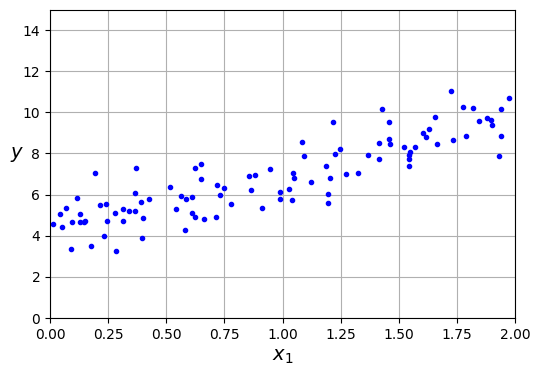

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

Why add the column of 1s? $$y = \theta_0 + \theta_1 x$$
Where:
* $\theta_0$ = intercept (bias)
* $\theta_1$ = slope

The added column of 1s allows us to write:

$$y = \begin{bmatrix} 1 & x \end{bmatrix} \begin{bmatrix} \theta_0 \\ \theta_1 \end{bmatrix}$$

In [11]:
from sklearn.preprocessing import add_dummy_feature
# print(X)
X_b = add_dummy_feature(X) # add x0 = 1 to each instance
# print(X_b)
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y) # (X^TX)^−1

In [12]:
theta_best

array([[4.21509616],
       [2.77011339]])

Step 1: Create New Inputs :
$$X_{\text{new}} = \begin{bmatrix} 0 & 2 \end{bmatrix}$$
Step 2: Add Dummy Feature :
Step 3: Make Predictions :
$$\hat{y} = X_{\text{new}} \hat{\theta}$$

In [13]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

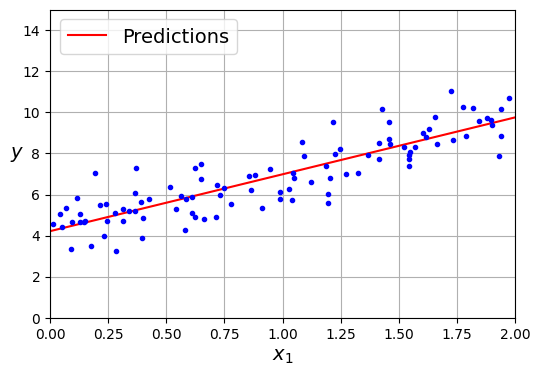

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

# extra code – beautifies and saves Figure 4–2
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
plt.show()


Gradient Descent : The general idea behinf GD is that iteratively tweak the parameter to minimize the cost function

Bias     = Model is too simple\
Variance = Model is too complex

The grdient formula used in the code is :
$$\nabla_\theta J(\theta) = \frac{2}{m} X^T (X\theta - y)$$

Where does this come from?\
The cost function for Linear Regression is:
$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

or in matrix form:

$$J(\theta) = \frac{1}{m} (X\theta - y)^T (X\theta - y)$$

Let's derive it for one feature
Model:

$$\hat y = \theta_0 + \theta_1x$$

Cost:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (\hat y_i-y_i)^2$$

Substitute $\hat y$:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (\theta_0+\theta_1x_i-y_i)^2$$

Derivative wrt $\theta_0$:

$$\frac{\partial J}{\partial \theta_0} = \frac{2}{m} \sum_{i=1}^{m} (\hat y_i-y_i)$$

Derivative wrt $\theta_1$:

$$\frac{\partial J}{\partial \theta_1} = \frac{2}{m} \sum_{i=1}^{m} (\hat y_i-y_i)x_i$$

Combine into Matrix Form
Instead of writing separate formulas for every parameter, we write:

$$\nabla_\theta J(\theta) = \frac{2}{m} X^T(X\theta-y)$$

Learned Parameters:
[[4.21509616]
 [2.77011339]]

Intercept (theta_0): 4.215096157546739
Slope (theta_1): 2.7701133864384917


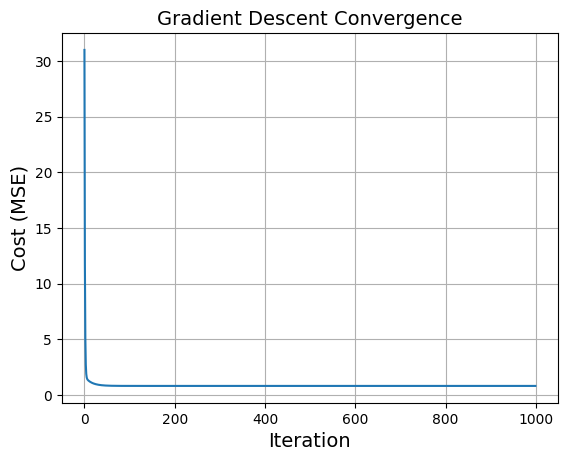

In [15]:
# Step 1: Generate Data
np.random.seed(42)
m = 100

X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

# Step 2: Add Bias Column
X_b = np.c_[np.ones((m, 1)), X] # Add bias term (x0 = 1)

# Step 3 : Initialize Parameters Randomly
theta = np.random.randn(2, 1)

# Hyperparameters
learning_rate = 0.1
n_iterations = 1000

# Store cost history
cost_history = []
# Step 6: Gradient Descent Loop
# Gradient Descent
for iteration in range(n_iterations):

    # Predictions
    y_pred = X_b @ theta

    # Compute cost (MSE)
    cost = np.mean((y_pred - y) ** 2)
    cost_history.append(cost)

    # Compute gradients
    gradients = (2 / m) * X_b.T @ (y_pred - y)

    # Update parameters
    theta = theta - learning_rate * gradients

print("Learned Parameters:")
print(theta)

print("\nIntercept (theta_0):", theta[0, 0])
print("Slope (theta_1):", theta[1, 0])

# Plot cost vs iteration
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.grid(True)
plt.show()

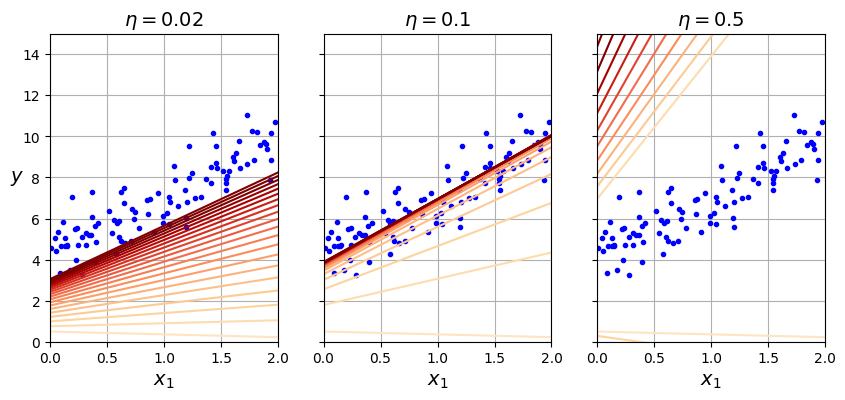

In [16]:

import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
plt.show()

Stochastic Gradient Descent : noiser but faster\
Batch Gradient Descent : Accurate but slower    

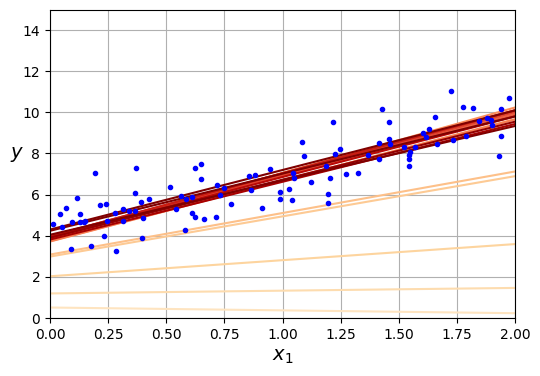

In [19]:
import numpy as np
import matplotlib.pyplot as plt
theta_path_sgd = []
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
  return t0 / (t1 + t)
np.random.seed(42)
theta = np.random.randn(2, 1)

n_shown = 20  # extra code – just needed to generate the figure below
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting

m = len(X_b)

for epoch in range(n_epochs):
  for iteration in range(m):

    # extra code – these 4 lines are used to generate the figure
    if epoch == 0 and iteration < n_shown:
        y_predict = X_new_b @ theta
        color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
        plt.plot(X_new, y_predict, color=color)

    random_index = np.random.randint(m)
    xi = X_b[random_index : random_index + 1]
    yi = y[random_index : random_index + 1]
    gradients = 2 * xi.T @ (xi @ theta - yi)
    eta = learning_schedule(epoch * m + iteration)
    theta = theta - eta * gradients
    theta_path_sgd.append(theta)  # extra code – to generate the figure

plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()